In [1]:
# **Objective:** Create meaningful features for churn prediction
# 
# **Features to create:**
# 1. Customer behavior features
# 2. Spending pattern features
# 3. Contract stability features
# 4. Service usage features
# 5. Temporal features
# 6. Interaction features
# 7. Advanced features (embeddings, polynomial)



# Set up

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif, f_classif
import warnings
warnings.filterwarnings('ignore')


# Load data

In [3]:
# Load data
df = pd.read_csv('../data/processed/eda_completed.csv')

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (7043, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket,ServiceCount
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-20%,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,40-60%,3
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-20%,3
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,60-80%,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-20%,1


In [4]:

# Define feature categories
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                       'PhoneService', 'MultipleLines', 'InternetService',
                       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                       'TechSupport', 'StreamingTV', 'StreamingMovies',
                       'Contract', 'PaperlessBilling', 'PaymentMethod']

target = 'Churn'


# FEATURE ENGINEERING 


In [5]:
features_df = pd.DataFrame(index=df.index)

# 1. CUSTOMER BEHAVIOR FEATURES

# Service count
services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
features_df['service_count'] = df[services].apply(lambda x: x.str.contains('Yes').sum(), axis=1)

# Premium services count
premium_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
features_df['premium_service_count'] = df[premium_services].apply(lambda x: x.str.contains('Yes').sum(), axis=1)

# Streaming services count
streaming_services = ['StreamingTV', 'StreamingMovies']
features_df['streaming_service_count'] = df[streaming_services].apply(lambda x: x.str.contains('Yes').sum(), axis=1)

# Internet user flag
features_df['has_internet'] = (df['InternetService'] != 'No').astype(int)

# Multiple lines flag
features_df['has_multiple_lines'] = (df['MultipleLines'] == 'Yes').astype(int)

# Paperless billing flag
features_df['paperless_billing'] = (df['PaperlessBilling'] == 'Yes').astype(int)

print(" Customer behavior features created")


# 2. SPENDING PATTERN FEATURES

# Monthly charges (already exists)
features_df['monthly_charges'] = df['MonthlyCharges']

# Total charges (already exists)
features_df['total_charges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Average monthly spend (same as monthly charges for now)
features_df['avg_monthly_spend'] = features_df['monthly_charges']

# Spend per tenure (average spend over lifetime)
features_df['spend_per_tenure'] = features_df['total_charges'] / (df['tenure'].replace(0, 1))

# Spend growth rate (if we had historical data, for now use proxy)
features_df['spend_growth_proxy'] = features_df['monthly_charges'] / (features_df['spend_per_tenure'] + 1)

# High spend flag
features_df['high_spend_flag'] = (features_df['monthly_charges'] > features_df['monthly_charges'].median()).astype(int)

# Spend stability (lower is more stable)
features_df['spend_volatility'] = features_df['monthly_charges'] / (features_df['total_charges'] + 1)

print(" Spending pattern features created")


# 3. CONTRACT STABILITY FEATURES

# Contract length score
contract_map = {'Month-to-month': 1, 'One year': 2, 'Two year': 3}
features_df['contract_length_score'] = df['Contract'].map(contract_map).fillna(1)

# Contract auto-renewal flag
features_df['has_autopay'] = df['PaymentMethod'].isin(['Bank transfer (automatic)', 'Credit card (automatic)']).astype(int)

# Early termination risk
features_df['early_termination_risk'] = (df['Contract'] == 'Month-to-month').astype(int)

# Tenure buckets
features_df['tenure_bucket'] = pd.qcut(df['tenure'], q=5, labels=False, duplicates='drop')

# Tenure risk score (lower tenure = higher risk)
features_df['tenure_risk_score'] = 1 - (df['tenure'] / df['tenure'].max())

# Long-term customer flag
features_df['long_term_customer'] = (df['tenure'] > df['tenure'].median()).astype(int)

print(" Contract stability features created")


# 4. SERVICE USAGE FEATURES

# Internet service type encoding
internet_map = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
features_df['internet_service_level'] = df['InternetService'].map(internet_map).fillna(0)

# Service bundle score
features_df['service_bundle_score'] = (
    features_df['service_count'] + 
    features_df['has_internet'] * 2 + 
    features_df['premium_service_count']
)

# Tech support dependency
features_df['tech_support_dependency'] = (
    features_df['has_internet'] * 
    features_df['premium_service_count']
)

# Streaming intensity
features_df['streaming_intensity'] = features_df['streaming_service_count'] / (features_df['service_count'] + 1)

print(" Service usage features created")

# 5. TEMPORAL FEATURES

# Tenure in years
features_df['tenure_years'] = df['tenure'] / 12

# Tenure months
features_df['tenure_months'] = df['tenure'] % 12

# Customer lifecycle stage
features_df['lifecycle_stage'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 24, 60, float('inf')],
    labels=[0, 1, 2, 3],  # New, Growing, Mature, Loyal
    include_lowest=True
).astype(int)

print(" Temporal features created")

# 6. INTERACTION FEATURES

# Contract x Tenure interaction
features_df['contract_tenure_interaction'] = features_df['contract_length_score'] * df['tenure']

# Services x Charges interaction
features_df['services_charges_interaction'] = features_df['service_count'] * features_df['monthly_charges']

# Internet x Premium services interaction
features_df['internet_premium_interaction'] = features_df['has_internet'] * features_df['premium_service_count']

# Tenure x Charges interaction
features_df['tenure_charges_interaction'] = df['tenure'] * features_df['monthly_charges']

print(" Interaction features created")

# 7. POLYNOMIAL FEATURES

# Square of monthly charges
features_df['monthly_charges_squared'] = features_df['monthly_charges'] ** 2

# Square root of tenure
features_df['tenure_sqrt'] = np.sqrt(df['tenure'] + 1)

# Log of total charges
features_df['total_charges_log'] = np.log(features_df['total_charges'] + 1)

print(" Polynomial features created")

# 8. RISK SCORE FEATURES

# Payment risk score
payment_risk_map = {
    'Electronic check': 1.0,
    'Mailed check': 0.8,
    'Bank transfer (automatic)': 0.3,
    'Credit card (automatic)': 0.2
}
features_df['payment_risk_score'] = df['PaymentMethod'].map(payment_risk_map).fillna(0.5)

# Overall risk score (simple weighted average)
features_df['overall_risk_score'] = (
    features_df['early_termination_risk'] * 0.3 +
    features_df['tenure_risk_score'] * 0.2 +
    features_df['payment_risk_score'] * 0.2 +
    (1 - features_df['contract_length_score'] / 3) * 0.2 +
    features_df['paperless_billing'] * 0.1
)

print(" Risk score features created")


 Customer behavior features created
 Spending pattern features created
 Contract stability features created
 Service usage features created
 Temporal features created
 Interaction features created
 Polynomial features created
 Risk score features created



# CATEGORICAL ENCODING


In [6]:

# One-hot encode categorical variables
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
                   'MultipleLines', 'InternetService', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport',
                   'StreamingTV', 'StreamingMovies', 'Contract', 
                   'PaperlessBilling', 'PaymentMethod']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_encoded = encoder.fit_transform(df[categorical_cols])

# Create DataFrame with encoded features
categorical_feature_names = []
for i, col in enumerate(categorical_cols):
    categories = encoder.categories_[i]
    for cat in categories:
        categorical_feature_names.append(f"{col}_{cat}")

categorical_df = pd.DataFrame(categorical_encoded, columns=categorical_feature_names, index=df.index)

# Concatenate with numerical features
features_all = pd.concat([features_df, categorical_df], axis=1)

print(f" Categorical encoding completed")
print(f"Total features created: {features_all.shape[1]}")


 Categorical encoding completed
Total features created: 76


# FEATURE SCALING

In [7]:

# Separate numerical features for scaling
numerical_feature_cols = features_df.columns.tolist()
numerical_features = features_all[numerical_feature_cols]

# Scale numerical features
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical_features)

# Create scaled DataFrame
numerical_scaled_df = pd.DataFrame(numerical_scaled, columns=numerical_feature_cols, index=features_all.index)

# Replace unscaled numerical features with scaled ones
features_scaled = features_all.copy()
features_scaled[numerical_feature_cols] = numerical_scaled_df

print(" Feature scaling completed")


 Feature scaling completed


# FEATURE IMPORTANCE ANALYSIS

In [8]:
# Convert target to binary
y = (df[target] == 'Yes').astype(int)

# Calculate mutual information
mi_scores = mutual_info_classif(features_scaled, y, random_state=42)
mi_df = pd.DataFrame({
    'feature': features_scaled.columns,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

print("\nTop 20 features by Mutual Information:")
display(mi_df.head(20))

# Calculate F-statistic
f_scores, p_values = f_classif(features_scaled, y)
f_df = pd.DataFrame({
    'feature': features_scaled.columns,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('f_score', ascending=False)

print("\nTop 20 features by F-statistic:")
display(f_df.head(20))



Top 20 features by Mutual Information:


,feature,mutual_info
34,overall_risk_score,0.133832
26,contract_tenure_interaction,0.103668
13,contract_length_score,0.099442
67,Contract_Month-to-month,0.090596
15,early_termination_risk,0.085317
27,services_charges_interaction,0.085053
12,spend_volatility,0.083120
58,TechSupport_No,0.071862
16,tenure_bucket,0.071169
23,tenure_years,0.071008



Top 20 features by F-statistic:


,feature,f_score,p_value
34,overall_risk_score,1783.459253,0.000000e+00
67,Contract_Month-to-month,1382.340697,1.991701e-276
15,early_termination_risk,1382.340697,1.991701e-276
13,contract_length_score,1315.088872,3.666675e-264
31,tenure_sqrt,1107.553001,1.119185e-225
26,contract_tenure_interaction,1072.958132,3.629090e-219
16,tenure_bucket,1036.993547,2.281309e-212
25,lifecycle_stage,1034.038142,8.283227e-212
23,tenure_years,997.268010,7.999058e-205
17,tenure_risk_score,997.268010,7.999058e-205


# FEATURE CORRELATION ANALYSIS


In [9]:
correlation_matrix = features_scaled.corr()

# Find highly correlated features (> 0.8 or < -0.8)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.8:
            high_corr_pairs.append({
                'feature1': correlation_matrix.columns[i],
                'feature2': correlation_matrix.columns[j],
                'correlation': corr
            })

if len(high_corr_pairs) > 0:
    print("\nHighly correlated feature pairs (|corr| > 0.8):")
    high_corr_df = pd.DataFrame(high_corr_pairs)
    display(high_corr_df)
else:
    print("\nNo highly correlated feature pairs found.")



Highly correlated feature pairs (|corr| > 0.8):


,feature1,feature2,correlation
0,service_count,premium_service_count,0.854678
1,service_count,monthly_charges,0.802322
2,service_count,avg_monthly_spend,0.802322
3,service_count,service_bundle_score,0.962658
4,service_count,tech_support_dependency,0.854678
...,...,...,...
134,DeviceProtection_No internet service,StreamingMovies_No internet service,1.000000
135,TechSupport_No internet service,StreamingTV_No internet service,1.000000
136,TechSupport_No internet service,StreamingMovies_No internet service,1.000000
137,StreamingTV_No internet service,StreamingMovies_No internet service,1.000000


# VISUALIZATION


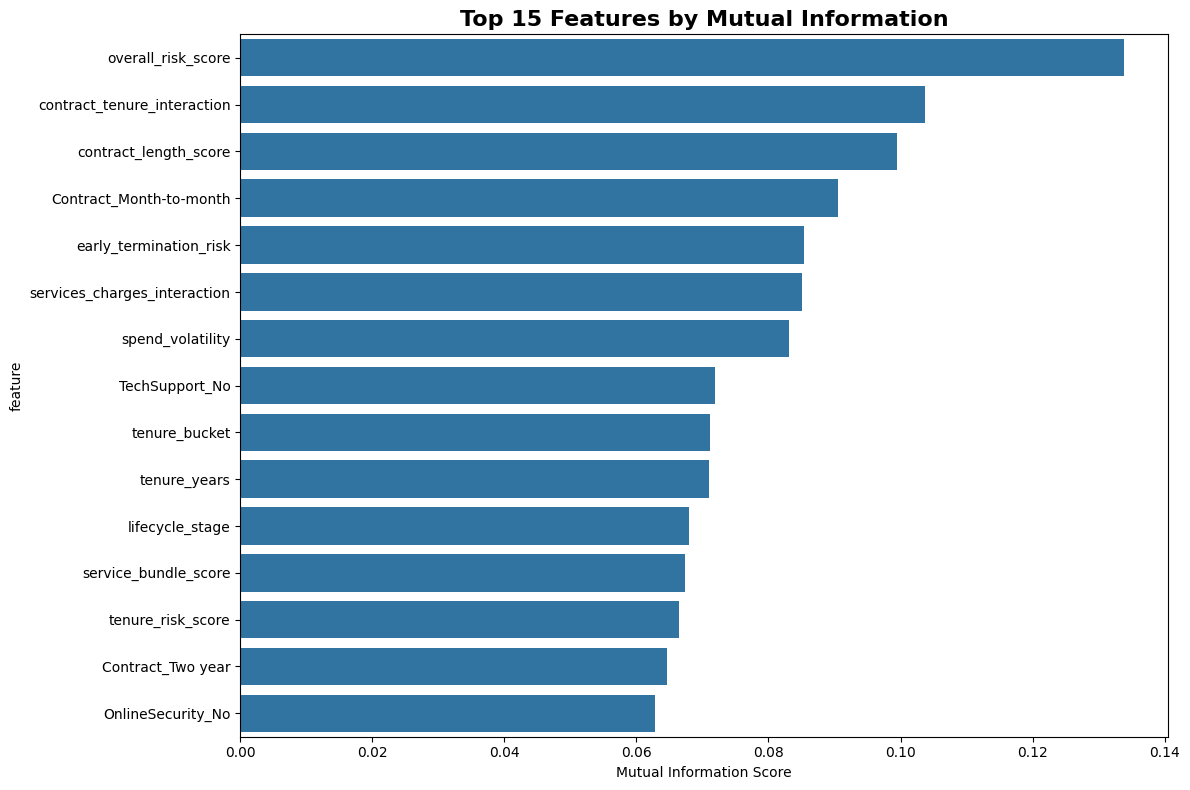

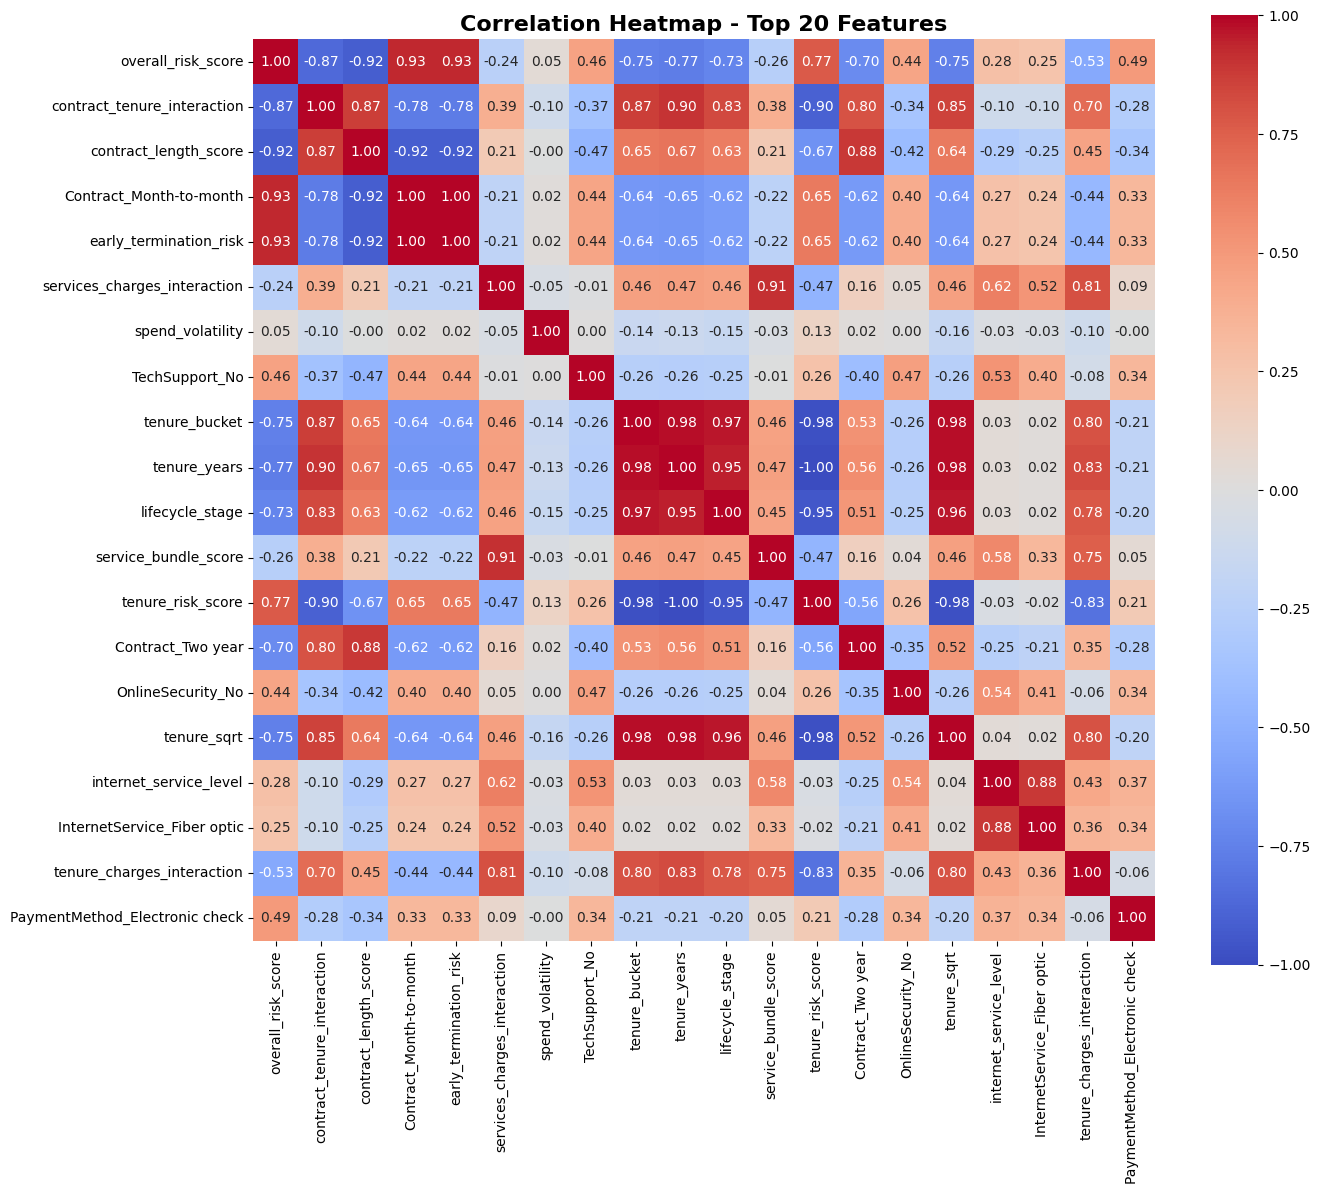

In [10]:


# Top features by mutual information
plt.figure(figsize=(12, 8))
top_mi = mi_df.head(15)
sns.barplot(x='mutual_info', y='feature', data=top_mi)
plt.title('Top 15 Features by Mutual Information', fontsize=16, fontweight='bold')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.savefig('../reports/figures/top_features_mi.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature correlation heatmap (top 20 features)
plt.figure(figsize=(14, 12))
top_features = mi_df.head(20)['feature'].tolist()
sns.heatmap(correlation_matrix.loc[top_features, top_features], 
            annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap - Top 20 Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


# SAVE FEATURES AND METADATA

In [11]:

# Save scaled features
features_scaled.to_csv('../data/processed/features_scaled.csv', index=False)

# Save target
y.to_csv('../data/processed/target.csv', index=False, header=True)

# Save feature importance
mi_df.to_csv('../data/processed/feature_importance_mi.csv', index=False)
f_df.to_csv('../data/processed/feature_importance_f.csv', index=False)

# Save scaler and encoder for inference
import joblib
joblib.dump(scaler, '../models/feature_scaler.pkl')
joblib.dump(encoder, '../models/categorical_encoder.pkl')

print("\n All features saved successfully!")
print(f"Final feature matrix shape: {features_scaled.shape}")
print(f"Target shape: {y.shape}")

# %%
# 15. SUMMARY STATISTICS

print("=" * 80)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 80)

print(f"\nTotal features created: {features_scaled.shape[1]}")
print(f"  - Numerical features: {len(numerical_feature_cols)}")
print(f"  - Categorical features (one-hot): {len(categorical_feature_names)}")

print(f"\nTop 5 most important features (by MI):")
for idx, row in mi_df.head(5).iterrows():
    print(f"  {idx+1}. {row['feature']}: {row['mutual_info']:.4f}")

print(f"\nFeatures with high correlation (|corr| > 0.8): {len(high_corr_pairs)}")

print(f"\nFeature value ranges:")
print(features_scaled.describe().loc[['min', 'max']].T.head(10))

print("\n" + "=" * 80)
print("✅ Feature engineering completed successfully!")
print("=" * 80)


 All features saved successfully!
Final feature matrix shape: (7043, 76)
Target shape: (7043,)
FEATURE ENGINEERING SUMMARY

Total features created: 76
  - Numerical features: 35
  - Categorical features (one-hot): 41

Top 5 most important features (by MI):
  35. overall_risk_score: 0.1338
  27. contract_tenure_interaction: 0.1037
  14. contract_length_score: 0.0994
  68. Contract_Month-to-month: 0.0906
  16. early_termination_risk: 0.0853

Features with high correlation (|corr| > 0.8): 139

Feature value ranges:
                              min       max
service_count           -1.630990  2.248955
premium_service_count   -0.983576  2.124939
streaming_service_count -0.905859  1.440147
has_internet            -1.901403  0.525927
has_multiple_lines      -0.854176  1.170719
paperless_billing       -1.205113  0.829798
monthly_charges         -1.545860  1.794352
total_charges           -1.005780  2.825806
avg_monthly_spend       -1.545860  1.794352
spend_per_tenure        -2.137475  1.8732